In [4]:
import pandas as pd
pd.options.plotting.backend ='plotly'
import plotly.express as px
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv('../annotations/toxicity/data_1_political_final.csv')
df2 = pd.read_csv('../annotations/toxicity/data_2_political_final.csv')
df = pd.concat([df1, df2])

# Remove duplicatas
df = df.drop_duplicates(subset=list(df.columns).remove('id'))

# Dataset length
print(len(df))

# Number of users
print(len(df['user'].unique()))

73019
817


In [ ]:
# Interactions by type
df['type'].hist()

In [ ]:
# Languages
df.loc[~df['language'].isin(['fr', 'en']), 'language']  = 'Other'
df['language'].hist()

In [ ]:
# Interactions by user
count_pays = df['user'].value_counts().reset_index()
count_pays.columns = ['user', 'nb_observations']

count_pays = count_pays.sort_values('nb_observations').reset_index(drop=True)

fig = px.line(
    count_pays,
    x=count_pays.index,
    y='nb_observations',
    markers=False,
    title="Nombre d'interactions par utilisateur (ordonné)"
)

fig.update_xaxes(showticklabels=True, title="Utilisateurs")
fig.update_yaxes(title="Nombre d'interactions")

fig.show()

In [ ]:
# Conversion en datetime
df['date'] = pd.to_datetime(df['date'])

obs_par_semaine = (
    df
    .set_index('date')
    .resample('W')
    .agg(
        nb_observations=('id', 'size'),
        nb_user_uniques=('user', 'nunique')
    )
    .reset_index()
)

# Plot
fig = px.line(
    obs_par_semaine,
    x='date',
    y=['nb_observations', 'nb_user_uniques'],
    markers=False,
    title="Nombre d'interactions et d'utilisateurs uniques par semaine"
)

fig.show()

In [ ]:
# Assurer le bon format de date
df['date'] = pd.to_datetime(df['date'])

# Calcul de la durée de vie par utilisateur
duree_vie = (
    df
    .groupby('user')['date']
    .agg(['min', 'max'])
)

# Durée de vie en jours
duree_vie['duree_jours'] = (duree_vie['max'] - duree_vie['min']).dt.days

# Statistiques
moyenne = duree_vie['duree_jours'].mean()
q25 = duree_vie['duree_jours'].quantile(0.25)
q75 = duree_vie['duree_jours'].quantile(0.75)

print(f"Durée de vie moyenne : {moyenne:.2f} jours")
print(f"Quantile 25% : {q25:.2f} jours")
print(f"Quantile 75% : {q75:.2f} jours")

/tmp/ipykernel_7215/389172957.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["trimestre"] = df["date"].dt.to_period("Q")


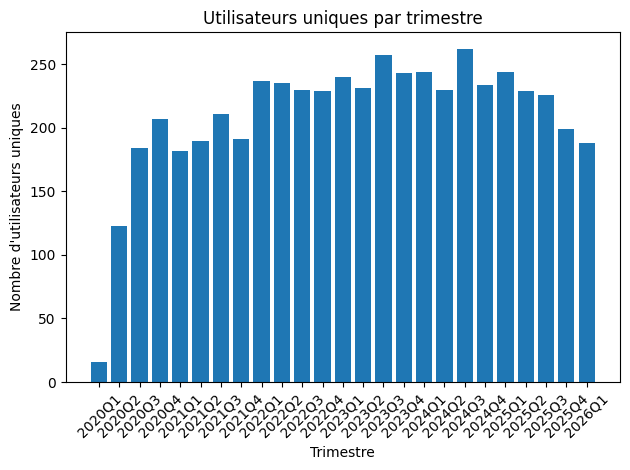

In [14]:
# Conversion en datetime
df["date"] = pd.to_datetime(df["date"])

# Création du trimestre
df["trimestre"] = df["date"].dt.to_period("Q")

# Nombre d'utilisateurs uniques par trimestre
quarterly_users = (
    df.groupby("trimestre")["user"]
    .nunique()
)

# Graphique
quarterly_users.index = quarterly_users.index.astype(str)
plt.bar(quarterly_users.index, quarterly_users.values)

plt.xlabel("Trimestre")
plt.ylabel("Nombre d'utilisateurs uniques")
plt.title("Utilisateurs uniques par trimestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("UtilisateursQ.png")

In [11]:
quarterly_users

trimestre
2020Q1     16
2020Q2    123
2020Q3    184
2020Q4    207
2021Q1    182
2021Q2    190
2021Q3    211
2021Q4    191
2022Q1    237
2022Q2    235
2022Q3    230
2022Q4    229
2023Q1    240
2023Q2    231
2023Q3    257
2023Q4    243
2024Q1    244
2024Q2    230
2024Q3    262
2024Q4    234
2025Q1    244
2025Q2    229
2025Q3    226
2025Q4    199
2026Q1    188
Freq: Q-DEC, Name: user, dtype: int64